# Verification: locally generated WSP polygons vs NHC official 5km shapefiles

Tests whether the polygons produced by `wsp_to_polygons()` in `tmp_gridded_outputs.ipynb`
are equivalent to the official NHC 5km GIS shapefiles from the same issuance.

Uses `2023082200` — the fixture timestamp present in both archives:
- **GRIB2**: `ftp.nhc.ncep.noaa.gov/wsp/2023/08/tpcprblty.2023082200.grib2.gz`
- **NHC 5km shapefile**: `nhc.noaa.gov/gis/forecast/archive/2023082200_wsp_120hr5km.zip`

## Checks
1. **Schema** — same columns and probability bin labels
2. **Coverage** — same set of non-empty bands per threshold
3. **Geometry area** — polygon areas agree within a tolerance
4. **Spatial overlap** — IoU (intersection-over-union) per band is high
5. **Visual comparison** — side-by-side plots for a qualitative check

In [1]:
import gzip
import io
import os
import tempfile
import zipfile

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cfgrib
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import rasterio.features
import rasterio.transform
import requests
import scipy.interpolate
import shapely.geometry
import shapely.ops
import xarray as xr

## 1. Fetch both sources

In [2]:
ISSUANCE = "2023082200"

# --- NHC official 5km shapefile ---
shp_url = f"https://www.nhc.noaa.gov/gis/forecast/archive/{ISSUANCE}_wsp_120hr5km.zip"
print(f"Fetching official shapefile: {shp_url}")
r_shp = requests.get(shp_url, timeout=60)
r_shp.raise_for_status()

# --- GRIB2 ---
grib_url = (
    f"https://ftp.nhc.ncep.noaa.gov/wsp/2023/08/tpcprblty.{ISSUANCE}.grib2.gz"
)
print(f"Fetching GRIB2: {grib_url}")
r_grib = requests.get(grib_url, timeout=120)
r_grib.raise_for_status()

Fetching official shapefile: https://www.nhc.noaa.gov/gis/forecast/archive/2023082200_wsp_120hr5km.zip
Fetching GRIB2: https://ftp.nhc.ncep.noaa.gov/wsp/2023/08/tpcprblty.2023082200.grib2.gz


## 2. Load the official NHC shapefiles

In [3]:
WSP_COLORS = {
    "<5%": "none",
    "5-10%": "#008B00",
    "10-20%": "#00CD00",
    "20-30%": "#7FFF00",
    "30-40%": "#FFFF00",
    "40-50%": "#FFD700",
    "50-60%": "#CD8500",
    "60-70%": "#FF7F00",
    "70-80%": "#CD0000",
    "80-90%": "#8B0000",
    ">90%": "#8B008B",
}


def load_official_shapefiles(zip_bytes: bytes) -> dict[int, gpd.GeoDataFrame]:
    """Load the three shapefiles from an NHC 5km zip into a dict keyed by kt."""
    result = {}
    with tempfile.TemporaryDirectory() as tmp:
        z = zipfile.ZipFile(io.BytesIO(zip_bytes))
        z.extractall(tmp)
        for kt in [34, 50, 64]:
            candidates = [
                f
                for f in z.namelist()
                if f.endswith(".shp") and f"wsp{kt}knt" in f
            ]
            if not candidates:
                continue
            gdf = gpd.read_file(os.path.join(tmp, candidates[0]))
            # Reproject to EPSG:4326 (official files use NCEP sphere)
            gdf = gdf.to_crs("EPSG:4326")
            # Drop the transparent <5% row — no geometry to compare
            gdf = gdf[gdf["PERCENTAGE"] != "<5%"].copy()
            gdf = gdf[gdf["geometry"].notna()].copy()
            gdf["fill"] = gdf["PERCENTAGE"].map(WSP_COLORS)
            result[kt] = gdf.rename(columns={"PERCENTAGE": "percentage"})
    return result


official = load_official_shapefiles(r_shp.content)
for kt, gdf in official.items():
    print(f"Official {kt}kt: {len(gdf)} bands — {gdf['percentage'].tolist()}")

Official 34kt: 10 bands — ['5-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '>90%']
Official 50kt: 4 bands — ['5-10%', '10-20%', '20-30%', '30-40%']
Official 64kt: 0 bands — []


## 3. Generate local polygons from GRIB2

In [4]:
KT_TO_SVUL = {34: 17491, 50: 25722, 64: 32924}
BIN_EDGES = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 101]
BIN_LABELS = [
    "5-10%",
    "10-20%",
    "20-30%",
    "30-40%",
    "40-50%",
    "50-60%",
    "60-70%",
    "70-80%",
    "80-90%",
    ">90%",
]
NHC_COLORS = [
    "#d0e8f0",
    "#008B00",
    "#00CD00",
    "#7FFF00",
    "#FFFF00",
    "#FFD700",
    "#CD8500",
    "#FF7F00",
    "#CD0000",
    "#8B0000",
    "#8B008B",
]
TARGET_DEG = 5 / 111.32
_EMPTY_GDF = gpd.GeoDataFrame(
    columns=["wind_kt", "percentage", "fill", "geometry"],
    geometry="geometry",
    crs="EPSG:4326",
)


def extract_wsp(grib_path: str) -> xr.Dataset:
    arrays = []
    for kt, svul in KT_TO_SVUL.items():
        ds = cfgrib.open_dataset(
            grib_path,
            filter_by_keys={
                "shortName": "10si",
                "stepRange": "0-120",
                "scaledValueOfUpperLimit": svul,
            },
            indexpath=None,
            decode_timedelta=False,
        )
        da = ds["si10"].assign_coords(wind_kt=kt).expand_dims("wind_kt")
        arrays.append(da)
    return xr.concat(arrays, dim="wind_kt").rename("probability").to_dataset()


def wsp_to_polygons(wsp: xr.Dataset, wind_kt: int) -> gpd.GeoDataFrame:
    da = wsp["probability"].sel(wind_kt=wind_kt)
    da = da.assign_coords(longitude=(da.longitude % 360) - 360).sortby(
        "longitude"
    )
    src_lats, src_lons = da.latitude.values, da.longitude.values
    dst_lats = np.arange(
        src_lats.min(), src_lats.max() + TARGET_DEG, TARGET_DEG
    )
    dst_lons = np.arange(
        src_lons.min(), src_lons.max() + TARGET_DEG, TARGET_DEG
    )
    dst_lon_grid, dst_lat_grid = np.meshgrid(dst_lons, dst_lats)
    interp = scipy.interpolate.RegularGridInterpolator(
        (src_lats, src_lons),
        da.values.astype(np.float64),
        method="linear",
        bounds_error=False,
        fill_value=0.0,
    )
    grid_5km = interp((dst_lat_grid, dst_lon_grid)).astype(np.float32)
    transform = rasterio.transform.from_bounds(
        dst_lons.min(),
        dst_lats.min(),
        dst_lons.max(),
        dst_lats.max(),
        grid_5km.shape[1],
        grid_5km.shape[0],
    )
    grid_flipped = np.flipud(grid_5km)
    rows = []
    for (lo, hi), label in zip(zip(BIN_EDGES[:-1], BIN_EDGES[1:]), BIN_LABELS):
        mask = ((grid_flipped >= lo) & (grid_flipped < hi)).astype(np.uint8)
        if mask.sum() == 0:
            continue
        polys = [
            shapely.geometry.shape(g)
            for g, v in rasterio.features.shapes(mask, transform=transform)
            if v == 1
        ]
        if not polys:
            continue
        rows.append(
            {
                "wind_kt": wind_kt,
                "percentage": label,
                "fill": NHC_COLORS[BIN_LABELS.index(label) + 1],
                "geometry": shapely.ops.unary_union(polys),
            }
        )
    if not rows:
        return _EMPTY_GDF.copy()
    return gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")


# Write GRIB2 to tempfile and generate
tmp = tempfile.NamedTemporaryFile(suffix=".grib2", delete=False)
tmp.write(gzip.decompress(r_grib.content))
tmp.close()
grib_path = tmp.name

wsp = extract_wsp(grib_path)
local = {kt: wsp_to_polygons(wsp, wind_kt=kt) for kt in [34, 50, 64]}
os.unlink(grib_path)

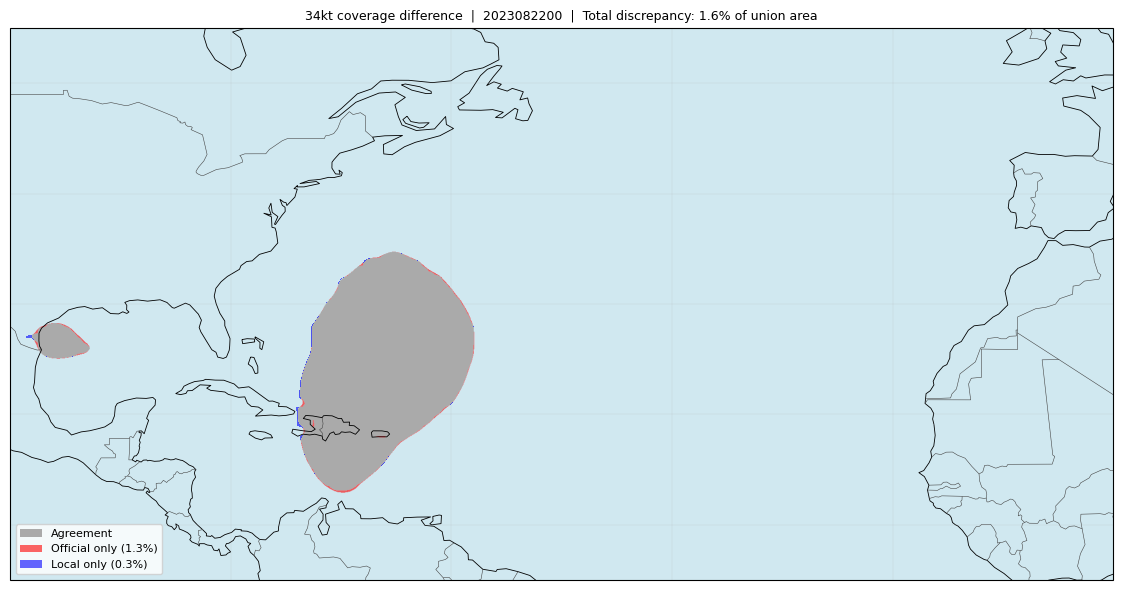

Total discrepancy: 1.64% of union area


In [5]:
# Difference map: areas in official but NOT local (red), in local but NOT official (blue)
off_union = shapely.ops.unary_union(official[34]["geometry"].tolist())
loc_union = shapely.ops.unary_union(local[34]["geometry"].tolist())

only_official = off_union.difference(loc_union)  # in official, not local
only_local = loc_union.difference(off_union)  # in local, not official

total_area = off_union.union(loc_union).area
pct_diff = (only_official.area + only_local.area) / total_area * 100

fig, ax = plt.subplots(
    figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.set_facecolor("#d0e8f0")
ax.set_extent([-100, 0, 5, 55], crs=ccrs.PlateCarree())

# Shared area (agreement)
shared = off_union.intersection(loc_union)
if not shared.is_empty:
    ax.add_geometries(
        [shared],
        crs=ccrs.PlateCarree(),
        facecolor="#aaaaaa",
        edgecolor="none",
        label="Agreement",
    )
if not only_official.is_empty:
    ax.add_geometries(
        [only_official],
        crs=ccrs.PlateCarree(),
        facecolor="red",
        edgecolor="none",
        alpha=0.6,
        label="Official only",
    )
if not only_local.is_empty:
    ax.add_geometries(
        [only_local],
        crs=ccrs.PlateCarree(),
        facecolor="blue",
        edgecolor="none",
        alpha=0.6,
        label="Local only",
    )

ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="#444")
ax.gridlines(linewidth=0.3, alpha=0.4)

ax.legend(
    handles=[
        mpatches.Patch(facecolor="#aaaaaa", label="Agreement"),
        mpatches.Patch(
            facecolor="red",
            alpha=0.6,
            label=f"Official only ({only_official.area / total_area * 100:.1f}%)",
        ),
        mpatches.Patch(
            facecolor="blue",
            alpha=0.6,
            label=f"Local only ({only_local.area / total_area * 100:.1f}%)",
        ),
    ],
    loc="lower left",
    fontsize=8,
)
ax.set_title(
    f"34kt coverage difference  |  {ISSUANCE}  |  "
    f"Total discrepancy: {pct_diff:.1f}% of union area",
    fontsize=9,
)
plt.tight_layout()
plt.show()

print(f"Total discrepancy: {pct_diff:.2f}% of union area")